In [ ]:
# Download data from cancer immunotherapy from GEO

# dataset from Squamous cell carcinoma, where we do have T cell data from before and after PD-1 immunotherapy

!mkdir -p data/GSE123813

!wget -q -P data/GSE123813 \
https://ftp.ncbi.nlm.nih.gov/geo/series/GSE123nnn/GSE123813/suppl/GSE123813_scc_metadata.txt.gz

!wget -q -P data/GSE123813 \
https://ftp.ncbi.nlm.nih.gov/geo/series/GSE123nnn/GSE123813/suppl/GSE123813_scc_scRNA_counts.txt.gz

In [ ]:
# For complementing information https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_pstime.html

In [ ]:
# import packages
import warnings
warnings.filterwarnings("ignore")

import decoupler as dc 
import pandas as pd
import scanpy as sc
import numpy as np

In [ ]:
DATA_DIR = "data/GSE123813"

metadata = pd.read_csv(f"{DATA_DIR}/GSE123813_scc_metadata.txt.gz", sep="\t")
counts = pd.read_csv(f"{DATA_DIR}/GSE123813_scc_scRNA_counts.txt.gz", sep="\t", index_col=0)

# create adata object
adata = sc.AnnData(counts.T)
adata.obs = metadata.set_index(metadata.columns[0]).loc[adata.obs_names]

In [ ]:
# subset adata for cleaner easy analysis
np.random.seed(42)  # reproducibility

cells = np.random.choice(adata.obs_names, size=3000, replace=False)
adata_sub = adata[cells].copy()

adata = adata_sub.copy()

In [ ]:
adata.obs['celltype'] = adata.obs['cluster']
adata.obs 
# we have different patients, at different time points (treatment) and different celltypes

,patient,treatment,cluster,UMAP1,UMAP2,celltype
scc.su011.post_TGCGGGTCAGTGAGTG,su011,post,CD8_mem,-3.915347,2.870814,CD8_mem
scc.su014.pre_AGGGTGAAGTCAAGCG,su014,pre,Th17,3.044236,-5.900887,Th17
scc.su014.pre_AGTCTTTAGAAGATTC,su014,pre,CD8_eff,-5.549964,-1.450922,CD8_eff
scc.su010.post.cd39_AGAGCTTAGGATGTAT,su010,post,CD8_ex,-4.015848,-1.700225,CD8_ex
scc.su013.pre_TCCCGATAGAATTGTG,su013,pre,Tfh,4.146600,-3.453251,Tfh
...,...,...,...,...,...,...
scc.su013.pre_GTGCAGCTCCTTTCGG,su013,pre,Naive,2.659678,0.620636,Naive
scc.su013.pre_AACACGTTCTCAAACG,su013,pre,Naive,2.529040,0.435245,Naive
scc.su011.pre.rep2_CGTCTACGTCTCACCT,su011,pre,CD8_ex,-3.923844,-2.438629,CD8_ex
scc.su013.pre_CATCAGACAGGGTATG,su013,pre,Treg,6.836407,2.924540,Treg


In [ ]:
# we need to subset for just one cell type CD4 or CD8
CD4 = ['Naive', 'Tfh', 'Th17', 'Treg']

adata = adata[adata.obs['cluster'].isin(CD4)]

In [ ]:
# We need to clean the data before our analysis
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True
)

adata = adata[
    (adata.obs.n_genes_by_counts.between(1000, 4000)) &
    (adata.obs.pct_counts_mt < 8) &
    (adata.obs.total_counts < 12000),
    :
]

In [ ]:
# Classical scanpy
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata,n_top_genes=2000)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
#sc.tl.paga(adata, groups="celltype")   # now yes.

sc.tl.umap(adata)
sc.tl.leiden(adata) #, flavor="igraph", n_iterations=2)


... storing 'patient' as categorical
... storing 'treatment' as categorical
... storing 'cluster' as categorical
... storing 'celltype' as categorical


In [ ]:
# It is very important to set up the root based on prior knowledge, because ....
# explain the difference between graphs?
# do they measure the distance based on umap???

root_celltype = "Naive"


sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.diffmap(adata)
sc.pp.neighbors(adata, use_rep="X_diffmap")
sc.tl.paga(adata, groups="celltype")

iroot = np.flatnonzero(adata.obs["celltype"] == root_celltype)[0]
adata.uns["iroot"] = iroot
sc.tl.dpt(adata)


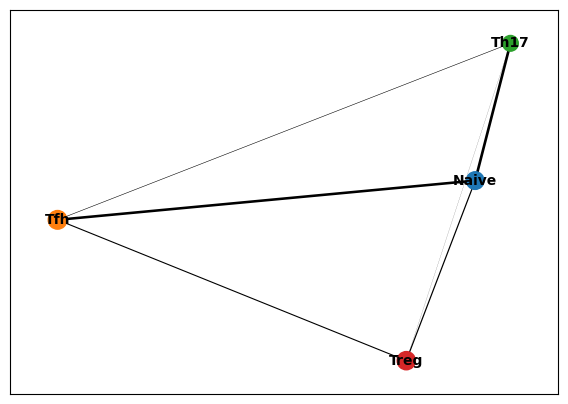

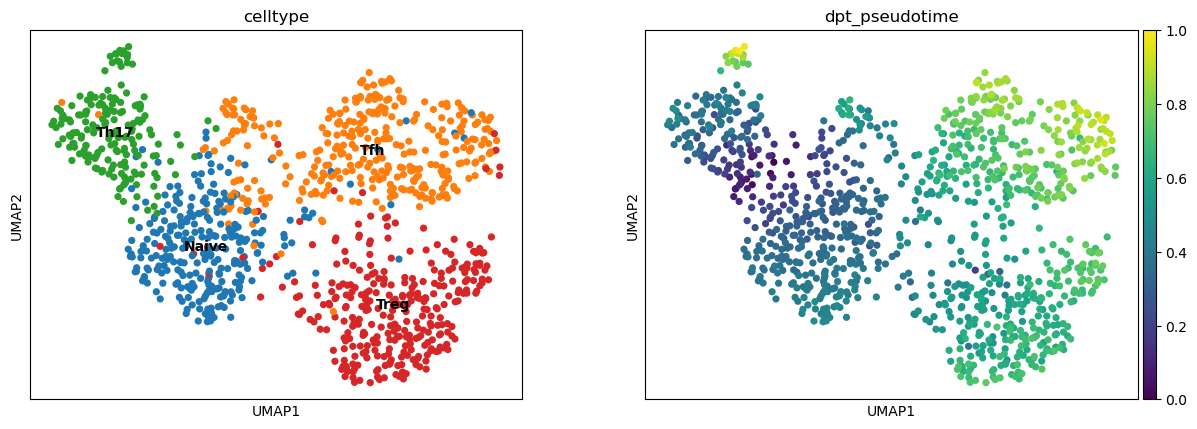

In [ ]:
sc.pl.paga(adata, color=["celltype"])
sc.pl.umap(adata, color=["celltype", "dpt_pseudotime"], legend_loc="on data")

In [ ]:
# Enrichment analysis
collectri = dc.op.collectri(organism="human")
#progeny = dc.op.progeny(organism="human")



In [ ]:
dc.mt.ulm(data=adata, net=collectri)
score = dc.pp.get_obsm(adata=adata, key="score_ulm")


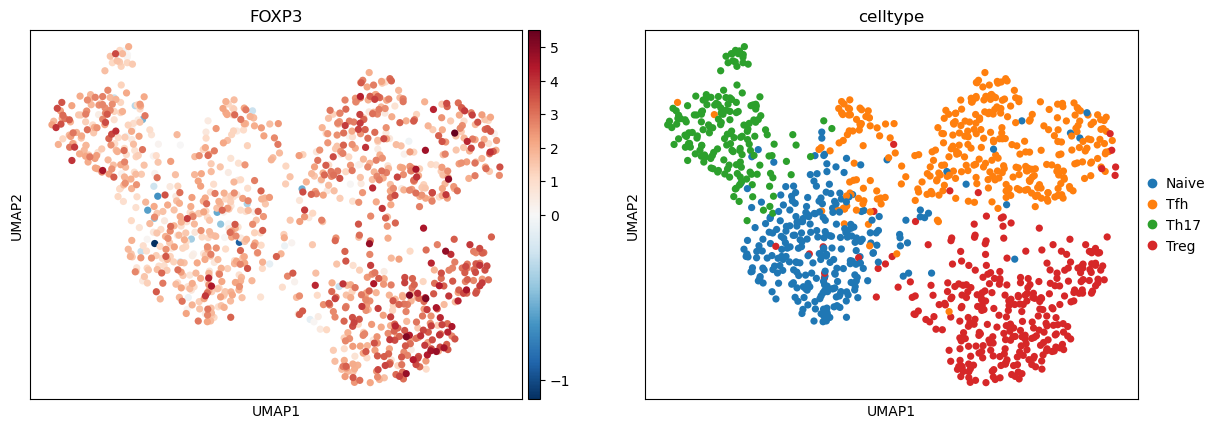

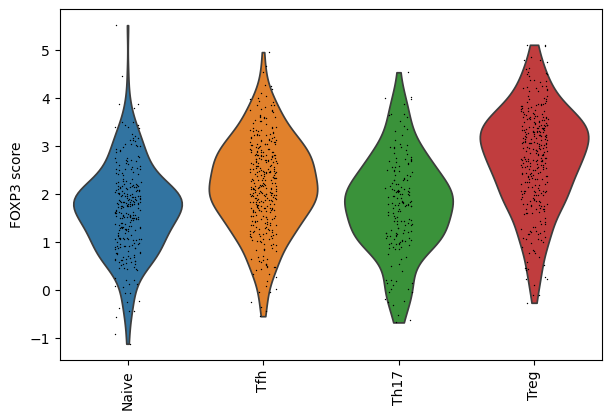

In [ ]:
tf = "FOXP3"
sc.pl.umap(score, color=[tf, "celltype"], cmap="RdBu_r", vcenter=0)
sc.pl.violin(score, keys=[tf], groupby="celltype", rotation=90, ylabel=f"{tf} score")

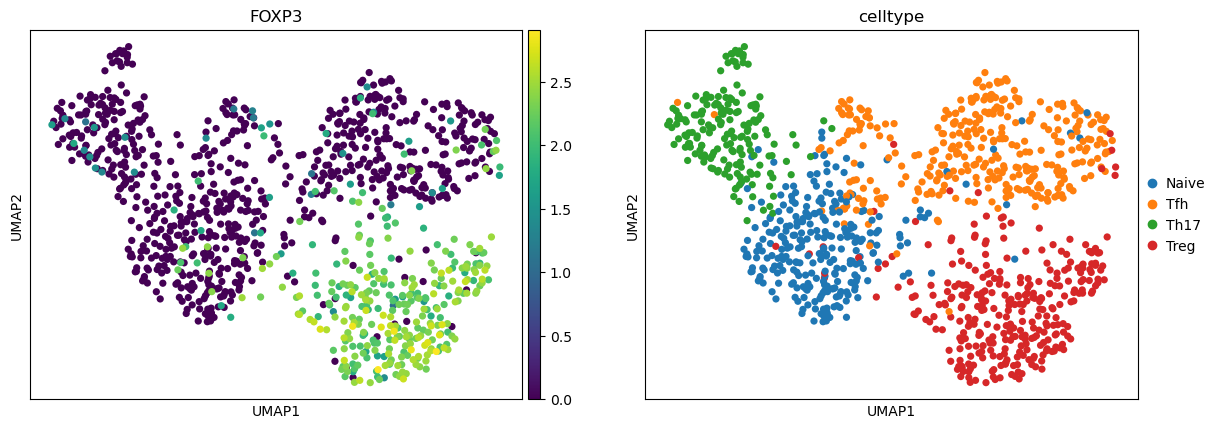

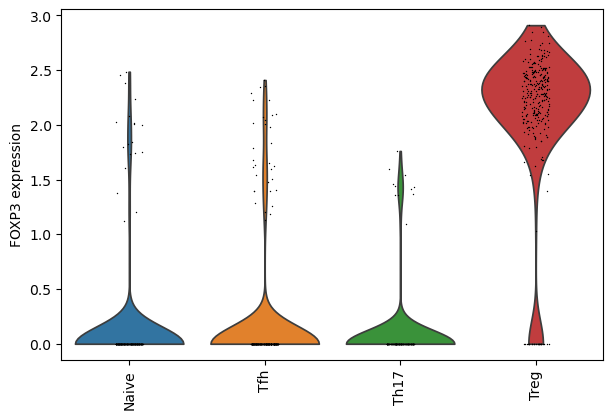

In [ ]:
sc.pl.umap(adata, color=[tf, "celltype"])
sc.pl.violin(adata, keys=[tf], groupby="celltype", rotation=90, ylabel=f"{tf} expression")

In [ ]:
tfs = dc.tl.rankby_order(
    adata=score,
    order="dpt_pseudotime",
    stat="dcor",
)
tfs

,name,impr,corr,pval,padj,sign
0,IRF7,0.160675,0.317377,2.380260e-27,4.697047e-26,1
1,HSF2,0.092660,0.471356,2.303530e-62,6.818448e-60,1
2,HSF1,0.079585,0.505332,7.266398e-73,4.301708e-70,1
3,NSD2,0.032182,-0.018686,5.343669e-01,5.858245e-01,0
4,HSF4,0.030112,0.457323,2.323704e-58,2.751265e-56,1
...,...,...,...,...,...,...
587,KDM5B,0.000000,0.038638,1.987415e-01,2.482173e-01,0
588,TBPL2,0.000000,0.114663,1.307375e-04,3.023305e-04,1
589,VDR,0.000000,0.241563,3.557119e-16,3.630714e-15,1
590,JUN,0.000000,0.418556,3.165382e-48,2.342383e-46,1


In [ ]:
top_tfs = tfs.head(5)["name"].to_list()
top_tfs

['IRF7', 'HSF2', 'HSF1', 'NSD2', 'HSF4']

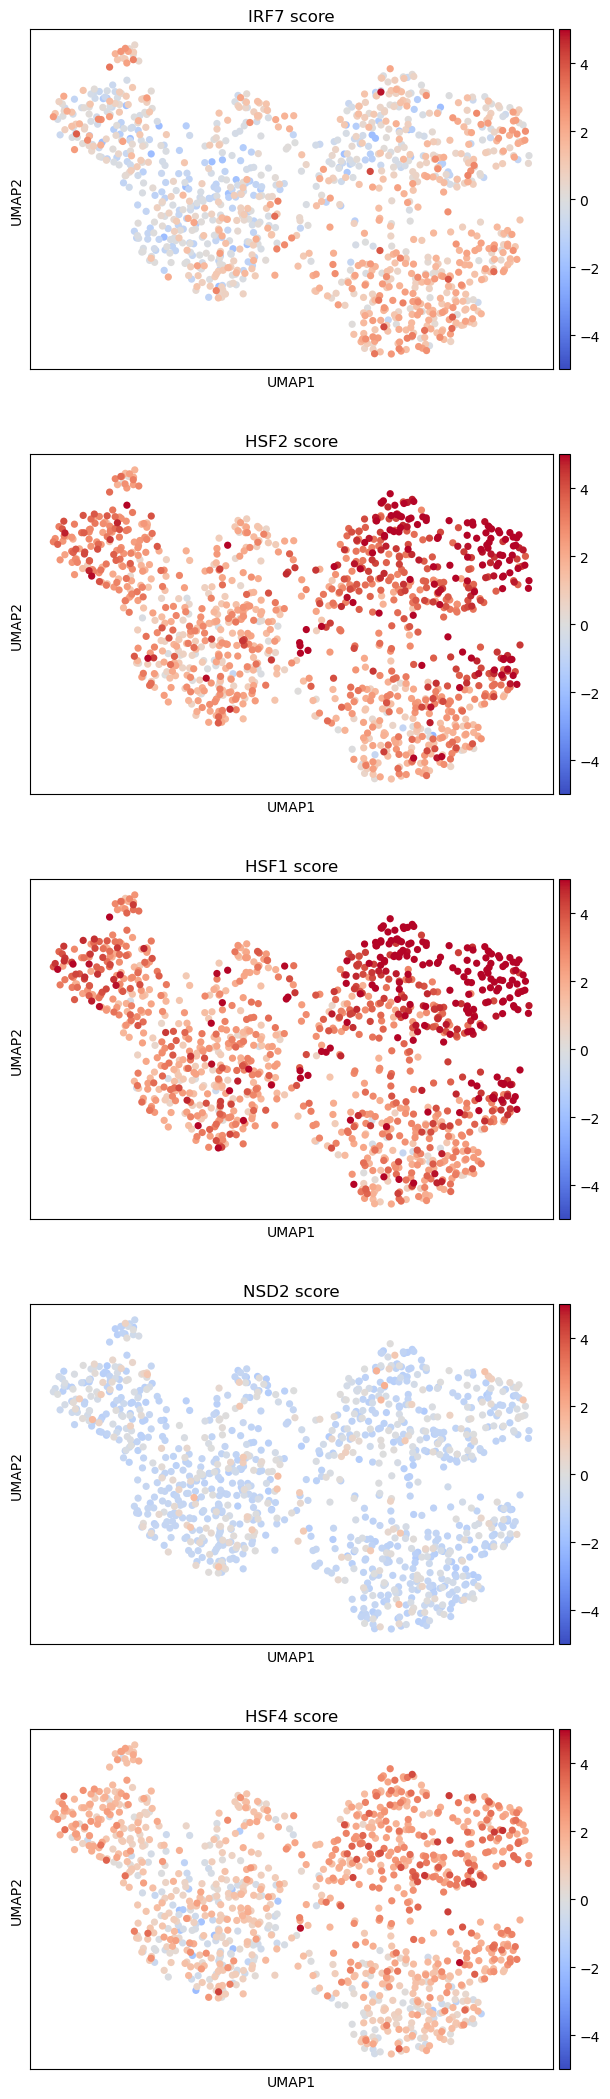

In [ ]:
sc.pl.umap(score, color=top_tfs, cmap="coolwarm", vmin=-5, vmax=5, ncols=1, title=[f"{t} score" for t in top_tfs])

In [ ]:
bin_tfs = dc.pp.bin_order(
    adata=score,
    order="dpt_pseudotime",
    names=top_tfs,
    label="celltype",
)
bin_tfs

,name,order,value,label,color
0,IRF7,0.005025,-0.123869,Naive,#1f77b4
1,IRF7,0.025126,-0.410584,Th17,#2ca02c
2,IRF7,0.035176,-1.153094,Th17,#2ca02c
3,IRF7,0.045226,0.228982,Th17,#2ca02c
4,IRF7,0.045226,0.453319,Naive,#1f77b4
...,...,...,...,...,...
5535,HSF4,0.939698,1.988572,Tfh,#ff7f0e
5536,HSF4,0.959799,2.137170,Tfh,#ff7f0e
5537,HSF4,0.969849,2.303441,Th17,#2ca02c
5538,HSF4,0.979899,1.224676,Th17,#2ca02c


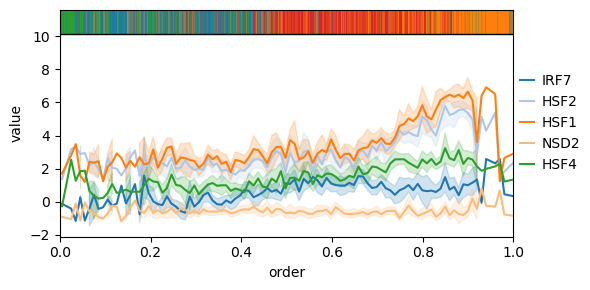

In [ ]:
dc.pl.order(
    df=bin_tfs,
    mode="line",
    figsize=(6, 3),
)

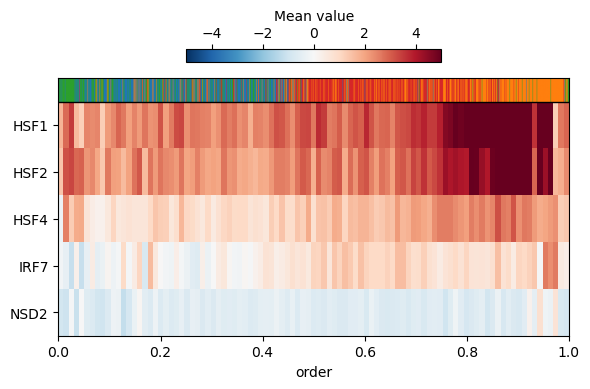

In [ ]:
dc.pl.order(df=bin_tfs, mode="mat", kw_order={"vmin": -5, "vmax": +5, "cmap": "RdBu_r"}, figsize=(6, 4))

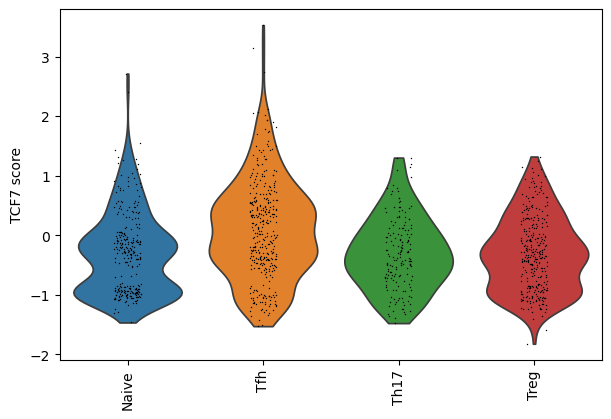

In [ ]:
tf = "TCF7"
sc.pl.violin(score, keys=[tf], groupby="celltype", rotation=90, ylabel=f"{tf} score")

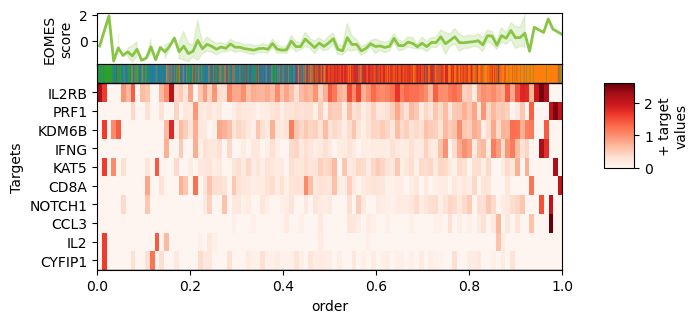

In [ ]:
dc.pl.order_targets(
    adata=adata,
    net=collectri,
    label="celltype",
    source="EOMES",
    order="dpt_pseudotime",
)